# Multitask RobotEmotions classifiers

This notebook builds the new multimodal evaluation dataset on top of the original RobotEmotions export pipeline, applies the correlation + DTW pose/IMU alignment, and runs the 7 experiment settings.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(root for root in candidate_roots if (root / 'pose_module').exists() and (root / 'evaluation').exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.classifiers import (
    ALL_CAPTURE_BLACKLIST,
    WindowedDatasetConfig,
    build_classifier_capture_table,
    build_windowed_multimodal_dataset,
)

try:
    from evaluation.classifiers import (
        EXPERIMENT_SPECS,
        ModelConfig,
        SplitConfig,
        TrainingConfig,
        run_experiment_suite,
    )
    TORCH_READY = True
    TORCH_IMPORT_ERROR = None
except ImportError as exc:
    TORCH_READY = False
    TORCH_IMPORT_ERROR = exc

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 260)
PROJECT_ROOT


PosixPath('/home/henriquesouza/IMUGPT')

## Dataset setup

The config below keeps the default 81-frame windows at 20 Hz. `max_windows_per_capture` is intentionally small here so the notebook stays responsive while we iterate; set it to `None` for the full evaluation sweep.

In [2]:
OUTPUT_ROOT = PROJECT_ROOT / 'output' / 'robot_emotions_virtual_imu_v2_all_dataset'
IMU_FEATURE_MODE = 'acc_euler'  # options: 'acc_gyro', 'acc_euler'
DATASET_CONFIG = WindowedDatasetConfig(
    window_size=81,
    overlap=0.5,
    synthetic_variant='raw',
    imu_feature_mode=IMU_FEATURE_MODE,
    selected_sensors=None,
    max_windows_per_capture=4,
    random_state=42,
)

CAPTURES_DF_ALL = build_classifier_capture_table(OUTPUT_ROOT, drop_blacklisted=False)
CAPTURES_DF = build_classifier_capture_table(OUTPUT_ROOT)
display(CAPTURES_DF[['clip_id', 'domain', 'user_id', 'tag_number', 'emotion', 'modality', 'stimulus', 'status']].head())
print({
    'num_captures_total_before_blacklist': len(CAPTURES_DF_ALL),
    'num_blacklisted_capture_specs': len(ALL_CAPTURE_BLACKLIST),
    'num_captures_after_blacklist': len(CAPTURES_DF),
    'domains': sorted(CAPTURES_DF['domain'].unique().tolist()),
})

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01,10ms,2,1,Neutrality,Standing,None,warning
1,robot_emotions_10ms_u02_tag05,10ms,2,5,Sadness,Sitting,Visual methods,warning
2,robot_emotions_10ms_u02_tag06,10ms,2,6,Sadness,Sitting,Autobiographical recall,warning
3,robot_emotions_10ms_u02_tag07,10ms,2,7,Sadness,Standing,Autobiographical recall,warning
4,robot_emotions_10ms_u02_tag09,10ms,2,9,Happiness,Sitting,Visual methods,warning


{'num_captures_total_before_blacklist': 89, 'num_blacklisted_capture_specs': 9, 'num_captures_after_blacklist': 80, 'domains': ['10ms', '30ms']}


## Dataset build and alignment diagnostics

This cell loads `pose3d.npz`, real `imu.npz`, and synthetic `virtual_imu.npz`, aligns real IMU to the pose timeline with correlation + DTW, and emits synchronized windows for pose, real IMU, and synthetic IMU.

In [3]:
DATASET_BUNDLE = build_windowed_multimodal_dataset(
    OUTPUT_ROOT,
    config=DATASET_CONFIG,
    captures_df=CAPTURES_DF,
)

display(DATASET_BUNDLE['metadata'].head())
display(DATASET_BUNDLE['alignment_summary'].head())
print({
    'num_samples': len(DATASET_BUNDLE['metadata']),
    'pose_shape': DATASET_BUNDLE['pose_windows'].shape,
    'imu_real_shape': DATASET_BUNDLE['imu_real_windows'].shape,
    'imu_synthetic_shape': DATASET_BUNDLE['imu_synthetic_windows'].shape,
    'imu_feature_mode': DATASET_BUNDLE['imu_feature_mode'],
    'selected_sensors': DATASET_BUNDLE['selected_sensors'],
})

,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,imu_feature_mode,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01::window_0000,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,160,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
1,robot_emotions_10ms_u02_tag01::window_0001,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,880,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
2,robot_emotions_10ms_u02_tag01::window_0002,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,2,1280,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
3,robot_emotions_10ms_u02_tag01::window_0003,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,3,1480,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
4,robot_emotions_10ms_u02_tag05::window_0000,robot_emotions_10ms_u02_tag05,robot_emotions_10ms_u02_tag05,10ms,2,5,1,Sadness,Sitting,Visual methods,Sadness|Sitting|Visual methods,10ms_user_02,0,160,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",13,0.433823,0.038990,0.567443,0.188057,0.997025,0.779515,0.001062,0.000233,6,0,3,11


,clip_id,selected_sensors,imu_feature_mode,lag_samples,lag_seconds,correlation_before_dtw,correlation_after_dtw,dtw_normalized_distance,aligned_frequency_hz,num_aligned_frames
0,robot_emotions_10ms_u02_tag01,"[waist, head, left_forearm, right_forearm]",acc_euler,-4,-0.133484,0.026847,0.671229,0.178128,29.966164,2082
1,robot_emotions_10ms_u02_tag05,"[waist, head, left_forearm, right_forearm]",acc_euler,13,0.433823,0.038990,0.567443,0.188057,29.966164,2075
2,robot_emotions_10ms_u02_tag06,"[waist, head, left_forearm, right_forearm]",acc_euler,-15,-0.500565,0.235031,0.712376,0.184795,29.966164,2150
3,robot_emotions_10ms_u02_tag07,"[waist, head, left_forearm, right_forearm]",acc_euler,0,0.000000,0.266520,0.766502,0.161656,29.966164,1938
4,robot_emotions_10ms_u02_tag09,"[waist, head, left_forearm, right_forearm]",acc_euler,9,0.300339,0.116164,0.561349,0.218361,29.966164,2041


{'num_samples': 320, 'pose_shape': (320, 81, 22, 16), 'imu_real_shape': (320, 81, 4, 12), 'imu_synthetic_shape': (320, 81, 4, 12), 'imu_feature_mode': 'acc_euler', 'selected_sensors': ['waist', 'head', 'left_forearm', 'right_forearm']}


,emotion,modality,stimulus,num_windows
0,Neutrality,Standing,None,36
1,Sadness,Sitting,Visual methods,32
2,Neutrality,Sitting,None,32
3,Happiness,Sitting,Visual methods,28
4,Happiness,Sitting,Autobiographical recall,28
5,Boredom,Sitting,Visual methods,28
6,Curiosity,Standing,Simulation,28
7,Sadness,Sitting,Autobiographical recall,24
8,Sadness,Standing,Autobiographical recall,24
9,Boredom,Standing,Visual methods,24


,lag_samples,correlation_after_dtw,dtw_normalized_distance
count,80.000000,80.000000,80.000000
mean,1.325000,0.615592,0.191772
std,14.024188,0.160407,0.034099
min,-20.000000,0.071088,0.152942
25%,-11.250000,0.555404,0.170511
50%,1.000000,0.646358,0.183319
75%,14.250000,0.729500,0.202906
max,20.000000,0.855669,0.384351


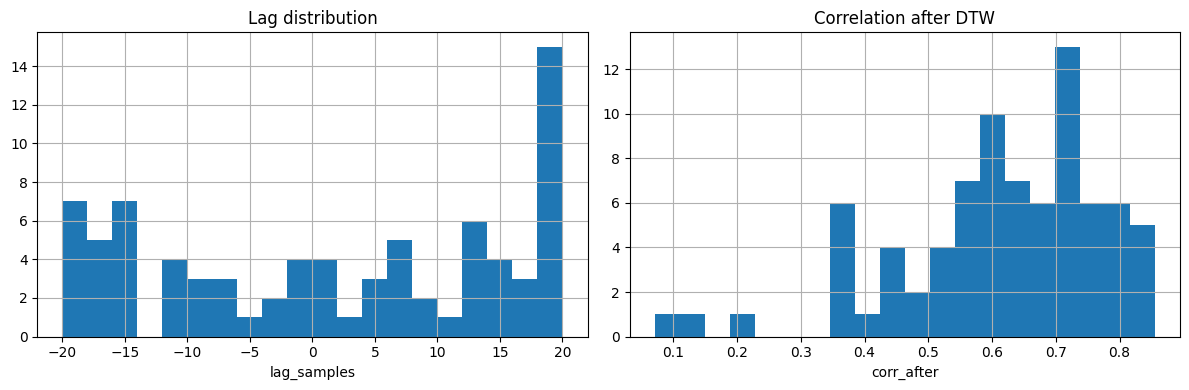

In [4]:
label_distribution = (
    DATASET_BUNDLE['metadata'][['emotion', 'modality', 'stimulus']]
    .value_counts()
    .rename('num_windows')
    .reset_index()
)
display(label_distribution.head(20))

alignment_summary = DATASET_BUNDLE['alignment_summary'][['lag_samples', 'correlation_after_dtw', 'dtw_normalized_distance']]
display(alignment_summary.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
DATASET_BUNDLE['alignment_summary']['lag_samples'].hist(ax=axes[0], bins=20)
axes[0].set_title('Lag distribution')
axes[0].set_xlabel('lag_samples')
DATASET_BUNDLE['alignment_summary']['correlation_after_dtw'].hist(ax=axes[1], bins=20)
axes[1].set_title('Correlation after DTW')
axes[1].set_xlabel('corr_after')
plt.tight_layout()


## Multitask experiment suite

The suite below runs the 7 experiment settings and reports the mean score across subject-group folds.


In [5]:
if not TORCH_READY:
    display(Markdown(f"**PyTorch is not available in the current `.venv`**: `{TORCH_IMPORT_ERROR}`"))
    SUITE_RESULT = None
else:
    SPLIT_CONFIG = SplitConfig(
        n_splits=5,
        random_state=42,
    )
    MODEL_CONFIG = ModelConfig(
        hidden_dim=128,
        dropout=0.1,
        trunk_blocks=2,
        modality_dropout_p=0.1,
    )
    TRAINING_CONFIG = TrainingConfig(
        batch_size=32,
        max_epochs=10,
        learning_rate=1e-3,
        weight_decay=1e-4,
        device='auto',
        domain_loss_weight=0.1,
        flat_tag_loss_weight=0.1,
        emotion_loss_weight=1.0,
        modality_loss_weight=1.0,
        stimulus_loss_weight=1.0,
        use_cb_focal=False,
    )
    SUITE_RESULT = run_experiment_suite(
        DATASET_BUNDLE,
        experiment_names=list(EXPERIMENT_SPECS.keys()),
        split_config=SPLIT_CONFIG,
        model_config=MODEL_CONFIG,
        training_config=TRAINING_CONFIG,
    )
    display(SUITE_RESULT['summary'])
    display(SUITE_RESULT['domain_gap_summary'])
    display(SUITE_RESULT['results_frame'])


,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1_supported_oof,emotion_macro_f1_all_oof,modality_macro_f1_oof,stimulus_macro_f1_oof,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,unsupported_classes,num_oof_samples
0,vision_imu_mixed2r,0.500379,0.443623,0.487362,0.424098,0.273354,0.234303,0.904762,0.323022,0.273354,0.904762,0.323022,emotion: Anger,320
1,imu_only_r2r,0.400853,0.360669,0.389419,0.343517,0.240115,0.205813,0.615369,0.347074,0.240115,0.615369,0.347074,emotion: Anger,320
2,vision_imu_r2r,0.443647,0.391848,0.432388,0.374959,0.236450,0.202671,0.793548,0.300944,0.236450,0.793548,0.300944,emotion: Anger,320
3,vision_only,0.418534,0.370530,0.407747,0.354350,0.226518,0.194158,0.740318,0.288766,0.226518,0.740318,0.288766,emotion: Anger,320
4,imu_only_s2r,0.388182,0.345336,0.377859,0.329851,0.216798,0.185827,0.649412,0.298337,0.216798,0.649412,0.298337,emotion: Anger,320
5,imu_only_mixed2r,0.418108,0.366473,0.408033,0.351361,0.211570,0.181346,0.674033,0.368721,0.211570,0.674033,0.368721,emotion: Anger,320
6,vision_imu_s2r,0.412963,0.361638,0.403074,0.346805,0.207663,0.177997,0.762463,0.268762,0.207663,0.762463,0.268762,emotion: Anger,320


,metric,value
0,imu_only_gap_s2r,0.012671
1,imu_only_gap_mixed2r,-0.017255
2,imu_only_gain_mixed_over_r2r,0.017255
3,imu_only_gain_mixed_over_s2r,0.029925
4,vision_imu_gap_s2r,0.030685
5,vision_imu_gap_mixed2r,-0.056732
6,vision_imu_gain_mixed_over_r2r,0.056732
7,vision_imu_gain_mixed_over_s2r,0.087417


,experiment_name,split_id,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1,emotion_macro_f1_all,modality_macro_f1,modality_macro_f1_all,stimulus_macro_f1,stimulus_macro_f1_all
0,vision_only,0,0.328421,0.275813,0.322802,0.267385,0.117989,0.101134,0.653202,0.653202,0.214071,0.214071
1,vision_only,1,0.394805,0.346045,0.385292,0.331776,0.199767,0.171228,0.773333,0.773333,0.211314,0.211314
2,vision_only,2,0.520088,0.464032,0.505999,0.442899,0.295866,0.253599,0.914324,0.914324,0.350074,0.350074
3,vision_only,3,0.197850,0.162277,0.195205,0.158308,0.055556,0.047619,0.347826,0.347826,0.190169,0.190169
4,vision_only,4,0.418625,0.370220,0.407910,0.354148,0.225006,0.192862,0.749756,0.749756,0.281113,0.281113
5,imu_only_r2r,0,0.412153,0.369585,0.400635,0.352307,0.241880,0.207326,0.686546,0.686546,0.308032,0.308032
6,imu_only_r2r,1,0.314972,0.269620,0.308612,0.260080,0.133564,0.114484,0.543229,0.543229,0.268122,0.268122
7,imu_only_r2r,2,0.425638,0.384303,0.413243,0.365711,0.260299,0.223113,0.714286,0.714286,0.302330,0.302330
8,imu_only_r2r,3,0.341623,0.303445,0.332627,0.289951,0.188913,0.161925,0.506463,0.506463,0.329492,0.329492
9,imu_only_r2r,4,0.370164,0.328933,0.360391,0.314273,0.205238,0.175919,0.540513,0.540513,0.364741,0.364741


## Optional confusion matrices

When the suite runs, this last block visualizes confusion matrices for the best experiment on its best fold.


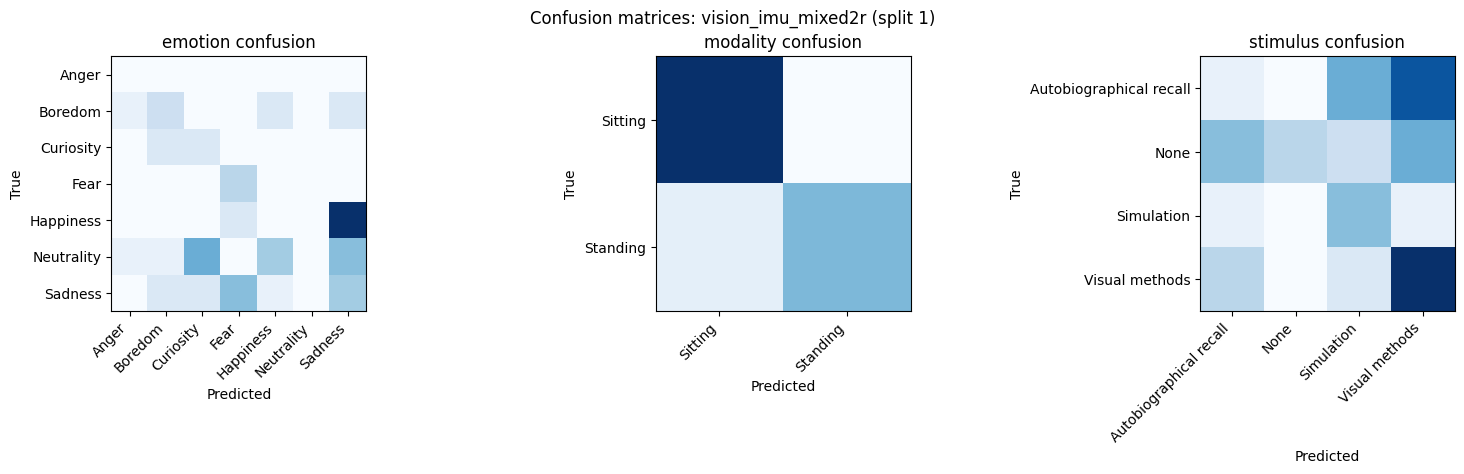

In [6]:
if SUITE_RESULT is not None:
    from evaluation.classifiers.metrics import plot_confusion_matrices

    best_experiment_name = SUITE_RESULT['summary'].iloc[0]['experiment_name']
    best_result = max(
        (
            result for result in SUITE_RESULT['results']
            if result['experiment_name'] == best_experiment_name
        ),
        key=lambda result: float(result['metrics'].get('global_score_macro_f1_mean') or float('-inf')),
    )
    best_split_id = best_result.get('split_id')
    fig, axes = plot_confusion_matrices(best_result['metrics'], DATASET_BUNDLE['label_encoders'])
    split_suffix = '' if best_split_id is None else f' (split {best_split_id})'
    fig.suptitle(f'Confusion matrices: {best_experiment_name}{split_suffix}', y=1.02)
    plt.show()
